In [1]:
# Import the libraries.
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from shapely.geometry import shape

In [2]:
# Load the original Building Footprints dataset.
building_raw = pd.read_csv("2020-building-footprints.csv")

In [3]:
# Create a working copy so the original dataset remains unchanged.
building = building_raw.copy()

In [4]:
# Define a function to check size, columns, data types, missing values and duplicate rows.
def check_dataframe(df, name):
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    
    # Preview the first five rows.
    display(df.head())

    # Check the data type of each column.
    print("\nData types:")
    display(df.dtypes.to_frame("data_type"))

    # Check missing values in each column.
    print("\nMissing values:")
    missing = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percentage": (df.isna().mean() * 100).round(2)
    })

    display(missing.sort_values("missing_percentage", ascending=False))

    # Count identical rows.
    print("\nDuplicate rows:", df.duplicated().sum())

In [5]:
# Check the building footprint dataset.
check_dataframe(building, "Building Footprints")

Shape: 37,750 rows × 13 columns


,Geo Point,Geo Shape,footprint_type,tier,structure_max_elevation,footprint_max_elevation,structure_min_elevation,property_id,structure_id,footprint_extrusion,footprint_min_elevation,structure_extrusion,roof_type
0,"-37.80037045080206, 144.9464370995547","{""coordinates"": [[[[144.94650487159868, -37.80...",Structure,1,24.5,24.5,15.0,107105.0,818620,9.5,15.0,9.5,Flat
1,"-37.80034679637949, 144.94754591875628","{""coordinates"": [[[[144.94761503800615, -37.80...",Structure,1,23.5,23.5,13.0,107102.0,805966,10.5,13.0,10.5,Flat
2,"-37.80027329346989, 144.94824324805376","{""coordinates"": [[[[144.94834088635758, -37.80...",Structure,1,24.0,24.0,13.0,107100.0,813265,10.5,13.0,11.0,Flat
3,"-37.800556970621834, 144.94811576128058","{""coordinates"": [[[[144.94818490989783, -37.80...",Structure,1,25.5,25.5,16.0,107100.0,813267,9.0,16.0,9.5,Flat
4,"-37.80167146256072, 144.94443776463496","{""coordinates"": [[[[144.9444642519418, -37.801...",Structure,2,21.0,21.0,14.5,105780.0,804769,7.0,14.5,6.5,Flat



Data types:


,data_type
Geo Point,object
Geo Shape,object
footprint_type,object
tier,int64
structure_max_elevation,float64
footprint_max_elevation,float64
structure_min_elevation,float64
property_id,float64
structure_id,int64
footprint_extrusion,float64



Missing values:


,missing_count,missing_percentage
property_id,14,0.04
Geo Shape,0,0.00
footprint_type,0,0.00
tier,0,0.00
Geo Point,0,0.00
structure_max_elevation,0,0.00
footprint_max_elevation,0,0.00
structure_min_elevation,0,0.00
structure_id,0,0.00
footprint_extrusion,0,0.00



Duplicate rows: 0


In [6]:
# Data Cleaning and Validation
# Define a function to standardise the column names of a dataset.
def standardise_column_names(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )

    return df

In [7]:
# Standardise the building-footprint column names.
building = standardise_column_names(building)

In [8]:
# Display the standardised column names.
print(building.columns.tolist())

['geo_point', 'geo_shape', 'footprint_type', 'tier', 'structure_max_elevation', 'footprint_max_elevation', 'structure_min_elevation', 'property_id', 'structure_id', 'footprint_extrusion', 'footprint_min_elevation', 'structure_extrusion', 'roof_type']


In [9]:
# Check the structure_id field.
building_identifier_check = pd.Series({
    "total_rows": len(building),
    "missing_structure_id": (
        building["structure_id"].isna().sum()
    ),
    "unique_structure_ids": (
        building["structure_id"].nunique(dropna=True)
    ),
    "duplicated_structure_id_values": (
        building["structure_id"]
        .dropna()
        .duplicated()
        .sum()
    )
})

display(building_identifier_check)

total_rows                        37750
missing_structure_id                  0
unique_structure_ids              19018
duplicated_structure_id_values    18732
dtype: int64

In [10]:
# Check whether structure_id and tier form a valid composite key.
building_composite_key_check = {
    "total_rows": len(building),

    "missing_structure_id": int(building["structure_id"].isna().sum()),

    "missing_tier": int(building["tier"].isna().sum()),

    "duplicated_structure_tier_pairs": int(building.duplicated(
        subset=["structure_id", "tier"]
    ).sum())
}

building_composite_key_check

{'total_rows': 37750,
 'missing_structure_id': 0,
 'missing_tier': 0,
 'duplicated_structure_tier_pairs': 34}

In [11]:
# Find all rows with duplicated structure_id and tier combinations.
duplicated_structure_tiers = (
    building[
        building.duplicated(
            subset=["structure_id", "tier"],
            keep=False
        )
    ]
    .sort_values(["structure_id", "tier"])
)

# Display the number and details of the affected rows.
print(
    "Rows involved in duplicated structure-tier pairs:",
    len(duplicated_structure_tiers)
)

display(duplicated_structure_tiers.head(30))

Rows involved in duplicated structure-tier pairs: 49


,geo_point,geo_shape,footprint_type,tier,structure_max_elevation,footprint_max_elevation,structure_min_elevation,property_id,structure_id,footprint_extrusion,footprint_min_elevation,structure_extrusion,roof_type
12937,"-37.79796782391274, 144.97167392824952","{""coordinates"": [[[[144.9717021875989, -37.797...",Structure,1,34.5,34.5,31.0,522663.0,802367,3.5,31.0,3.5,Flat
23854,"-37.79799404283372, 144.97167778381635","{""coordinates"": [[[[144.9717021875989, -37.797...",Structure,1,39.5,37.5,31.0,522663.0,802367,6.5,31.5,6.5,Flat
2133,"-37.797999253076696, 144.97172294653643","{""coordinates"": [[[[144.97174384912444, -37.79...",Structure,1,39.5,37.5,31.0,522664.0,805341,6.5,31.5,6.5,Flat
32561,"-37.797963694072685, 144.97173795816798","{""coordinates"": [[[[144.97174641668326, -37.79...",Structure,1,34.5,34.5,31.0,522664.0,805341,3.5,31.0,3.5,Flat
7417,"-37.83101124017178, 144.98685065681758","{""coordinates"": [[[[144.98690745964643, -37.83...",Structure,1,21.5,16.5,13.0,102018.0,813698,3.5,13.0,3.5,Flat
12938,"-37.830929765845575, 144.9868640641961","{""coordinates"": [[[[144.9869109096963, -37.830...",Structure,1,19.0,19.0,13.0,102018.0,813698,6.0,13.0,6.0,Flat
14917,"-37.8093637189285, 144.98142521289012","{""coordinates"": [[[[144.98147266506498, -37.80...",Structure,9,82.2,77.8,32.0,704480.0,819197,5.4,72.4,45.8,Flat
20530,"-37.809642116560404, 144.98173629073807","{""coordinates"": [[[[144.98155216405075, -37.80...",Structure,9,82.2,76.9,32.0,704479.0,819197,4.0,72.9,44.9,Flat
1197,"-37.796421467445505, 144.95853164781622","{""coordinates"": [[[[144.95842888092372, -37.79...",Structure,2,60.0,60.0,38.5,703688.0,819206,5.5,54.5,21.5,Flat
11348,"-37.7963040514288, 144.95877393203295","{""coordinates"": [[[[144.95867427427675, -37.79...",Structure,2,60.0,57.0,38.5,703688.0,819206,2.5,54.5,18.5,Flat


In [12]:
# Check the main building category values.
print("Footprint types:")
display(
    building["footprint_type"]
    .value_counts(dropna=False)
)

print("\nRoof types:")
display(
    building["roof_type"]
    .value_counts(dropna=False)
)

print("\nTier values:")
display(
    building["tier"]
    .value_counts(dropna=False)
    .sort_index()
)

Footprint types:


footprint_type
Structure         37142
Tram Stop           281
Bridge              183
Jetties              63
Toilet               45
Train Platform       25
Ramp                 11
Name: count, dtype: int64


Roof types:


roof_type
Flat       22053
Hip         8440
Gable       6902
Pyramid      257
Shed          98
Name: count, dtype: int64


Tier values:


tier
1     19011
2     10460
3      4353
4      1582
5       795
6       468
7       298
8       198
9       151
10      103
11       67
12       47
13       35
14       28
15       25
16       22
17       15
18       12
19       12
20       12
21        8
22        8
23        6
24        6
25        4
26        4
27        4
28        4
29        3
30        3
31        3
32        2
33        1
Name: count, dtype: int64

In [13]:
# Convert building identifier and tier fields to nullable integers.
building_integer_columns = [
    "property_id",
    "structure_id",
    "tier"
]

for column in building_integer_columns:
    building[column] = (
        pd.to_numeric(
            building[column],
            errors="coerce"
        )
        .astype("Int64")
    )

# Check missing values after conversion.
display(
    building[building_integer_columns]
    .isna()
    .sum()
)

property_id     14
structure_id     0
tier             0
dtype: int64

In [14]:
# Convert GeoJSON values to Shapely geometry.
def parse_geojson_geometry(value):
    if pd.isna(value):
        return None

    try:
        geojson_object = (
            json.loads(value)
            if isinstance(value, str)
            else value
        )

        return shape(geojson_object)

    except (
        json.JSONDecodeError,
        TypeError,
        ValueError,
        KeyError
    ):
        return None


# Parse the building-footprint GeoJSON geometry.
building["geometry"] = building["geo_shape"].apply(
    parse_geojson_geometry
)

# Convert the DataFrame to a GeoDataFrame.
building_gdf = gpd.GeoDataFrame(
    building.copy(),
    geometry="geometry",
    crs="EPSG:4326"
)

# Identify geometry-quality issues.
missing_geometry = building_gdf.geometry.isna()

empty_geometry = (
    building_gdf.geometry.notna()
    & building_gdf.geometry.is_empty
)

invalid_geometry = (
    building_gdf.geometry.notna()
    & ~building_gdf.geometry.is_empty
    & ~building_gdf.geometry.is_valid
)

parsing_failure = (
    building["geo_shape"].notna()
    & building["geometry"].isna()
)

# Summarise geometry quality.
building_geometry_quality = pd.Series({
    "total_records": len(building_gdf),
    "missing_geometry": missing_geometry.sum(),
    "parsing_failures": parsing_failure.sum(),
    "empty_geometry": empty_geometry.sum(),
    "invalid_geometry": invalid_geometry.sum()
})

print("Building Footprints geometry types:")

display(
    building_gdf.geometry
    .apply(
        lambda geometry: (
            geometry.geom_type
            if geometry is not None
            else "Missing"
        )
    )
    .value_counts()
)

display(building_geometry_quality)

Building Footprints geometry types:


geometry
MultiPolygon    37746
Polygon             4
Name: count, dtype: int64

total_records       37750
missing_geometry        0
parsing_failures        0
empty_geometry          0
invalid_geometry        0
dtype: int64

In [15]:
# Create the final cleaned Building Footprints dataset.
building_clean = building_gdf.copy()

# Clean the building category fields.
for column in ["footprint_type", "roof_type"]:
    building_clean[column] = (
        building_clean[column]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

# Add a unique identifier for every footprint record.
building_clean = building_clean.reset_index(drop=True)

building_clean.insert(
    0,
    "footprint_record_id",
    np.arange(
        1,
        len(building_clean) + 1,
        dtype=np.int64
    )
)

# Project the geometry for area calculations in square metres.
PROJECTED_CRS = "EPSG:7855"
building_projected = building_clean.to_crs(PROJECTED_CRS)

In [16]:
# Validate the cleaned building category fields.
for column in ["footprint_type", "roof_type"]:
    assert building_clean[column].notna().all()

    assert building_clean[column].eq(
        building_clean[column].str.strip()
    ).all()

print("Building category fields passed validation.")

Building category fields passed validation.


In [17]:
# Calculate Building Footprint Areas
# Calculate the area of each footprint polygon in square metres.
building_projected["footprint_area_m2"] = (
    building_projected.geometry.area
)

# Add the calculated area to the final cleaned dataset.
building_clean["footprint_area_m2"] = (
    building_projected["footprint_area_m2"]
)

# Identify missing, non-positive and extremely small areas.
missing_footprint_areas = (
    building_projected["footprint_area_m2"].isna()
)

non_positive_footprint_areas = (
    building_projected["footprint_area_m2"] <= 0
)

very_small_footprint_areas = (
    (building_projected["footprint_area_m2"] > 0) &
    (building_projected["footprint_area_m2"] < 0.01)
)

# Display the area distribution and validation results.
display(
    building_projected["footprint_area_m2"]
    .describe()
    .round(2)
)

print(
    "Missing footprint areas:",
    missing_footprint_areas.sum()
)

print(
    "Non-positive footprint areas:",
    non_positive_footprint_areas.sum()
)

print(
    "Positive areas below 0.01 m²:",
    very_small_footprint_areas.sum()
)

count     37750.00
mean        413.62
std        2171.47
min           0.00
25%          35.03
50%          73.03
75%         217.60
max      195473.28
Name: footprint_area_m2, dtype: float64

Missing footprint areas: 0
Non-positive footprint areas: 0
Positive areas below 0.01 m²: 1


In [18]:
# Validate Elevation and Extrusion Fields
# Recalculate extrusion values to check internal consistency.
calculated_footprint_extrusion = (
    building_clean["footprint_max_elevation"] -
    building_clean["footprint_min_elevation"]
)

calculated_structure_extrusion = (
    building_clean["footprint_max_elevation"] -
    building_clean["structure_min_elevation"]
)

# Compare the calculated values with the source extrusion fields.
footprint_extrusion_difference = (
    building_clean["footprint_extrusion"] -
    calculated_footprint_extrusion
).abs()

structure_extrusion_difference = (
    building_clean["structure_extrusion"] -
    calculated_structure_extrusion
).abs()

extrusion_differences = pd.DataFrame({
    "footprint_extrusion_difference":
        footprint_extrusion_difference,
    "structure_extrusion_difference":
        structure_extrusion_difference
})

display(extrusion_differences.describe().round(3))

# Count missing comparisons and differences above 0.1 metres.
extrusion_tolerance_m = 0.1

print(
    "Missing footprint comparisons:",
    footprint_extrusion_difference.isna().sum()
)

print(
    "Missing structure comparisons:",
    structure_extrusion_difference.isna().sum()
)

print(
    "Footprint differences above 0.1 m:",
    (
        footprint_extrusion_difference >
        extrusion_tolerance_m
    ).sum()
)

print(
    "Structure differences above 0.1 m:",
    (
        structure_extrusion_difference >
        extrusion_tolerance_m
    ).sum()
)

,footprint_extrusion_difference,structure_extrusion_difference
count,37750.000,37750.0
mean,0.122,0.0
std,0.215,0.0
min,0.000,0.0
25%,0.000,0.0
50%,0.000,0.0
75%,0.000,0.0
max,0.500,0.0


Missing footprint comparisons: 0
Missing structure comparisons: 0
Footprint differences above 0.1 m: 9199
Structure differences above 0.1 m: 0


In [19]:
# Create a Structure-Level Dataset
# Combine all unique non-missing values in a column.
def combine_unique_values(series):
    values = (
        series
        .dropna()
        .astype("string")
        .str.strip()
        .unique()
    )

    if len(values) == 0:
        return pd.NA

    return " | ".join(sorted(values))


# Aggregate building-footprint records into one row per structure.
structure_attributes = (
    building_clean
    .groupby("structure_id", as_index=False)
    .agg(
        property_ids=(
            "property_id",
            combine_unique_values
        ),
        property_id_count=(
            "property_id",
            "nunique"
        ),
        polygon_record_count=(
            "footprint_record_id",
            "size"
        ),
        tier_count=(
            "tier",
            "nunique"
        ),
        minimum_tier=(
            "tier",
            "min"
        ),
        maximum_tier=(
            "tier",
            "max"
        ),
        footprint_types=(
            "footprint_type",
            combine_unique_values
        ),
        footprint_type_count=(
            "footprint_type",
            "nunique"
        ),
        roof_types=(
            "roof_type",
            combine_unique_values
        ),
        roof_type_count=(
            "roof_type",
            "nunique"
        ),
        minimum_elevation_m=(
            "structure_min_elevation",
            "min"
        ),
        maximum_elevation_m=(
            "structure_max_elevation",
            "max"
        )
    )
)

# Calculate the total elevation range of each structure.
structure_attributes["structure_height_m"] = (
    structure_attributes["maximum_elevation_m"] -
    structure_attributes["minimum_elevation_m"]
)

# Check structures containing multiple categorical values.
structure_attribute_conflicts = pd.Series({
    "multiple_property_ids": (
        structure_attributes["property_id_count"] > 1
    ).sum(),
    "multiple_footprint_types": (
        structure_attributes["footprint_type_count"] > 1
    ).sum(),
    "multiple_roof_types": (
        structure_attributes["roof_type_count"] > 1
    ).sum()
})

display(structure_attribute_conflicts)
display(structure_attributes.head())

multiple_property_ids        124
multiple_footprint_types      76
multiple_roof_types         7097
dtype: int64

,structure_id,property_ids,property_id_count,polygon_record_count,tier_count,minimum_tier,maximum_tier,footprint_types,footprint_type_count,roof_types,roof_type_count,minimum_elevation_m,maximum_elevation_m,structure_height_m
0,800000,109491,1,3,3,1,3,Structure,1,Flat | Gable,2,20.0,65.0,45.0
1,800001,105870,1,4,4,1,4,Structure,1,Flat | Gable | Hip,3,16.5,25.0,8.5
2,800002,100752,1,4,4,1,4,Structure,1,Flat | Hip,2,35.0,42.5,7.5
3,800003,615329,1,2,2,1,2,Structure,1,Flat,1,2.5,10.0,7.5
4,800004,615369,1,2,2,1,2,Structure,1,Flat | Hip,2,5.5,9.5,4.0


In [20]:
# Create the Structure-Level GeoDataFrame
# Dissolve all footprint polygons into one planar geometry per structure.
structure_geometry = (
    building_projected[["structure_id", "geometry"]]
    .dissolve(by="structure_id")
    .reset_index()
)

# Add the aggregated structure attributes.
structure_gdf = structure_geometry.merge(
    structure_attributes,
    on="structure_id",
    how="left",
    validate="one_to_one"
)

structure_gdf = gpd.GeoDataFrame(
    structure_gdf,
    geometry="geometry",
    crs=PROJECTED_CRS
)

# Calculate the area of each dissolved structure-footprint union.
structure_gdf["structure_footprint_area_m2"] = (
    structure_gdf.geometry.area
)

# Identify geometry and measurement issues.
missing_structure_geometry = (
    structure_gdf.geometry.isna()
)

empty_structure_geometry = (
    structure_gdf.geometry.notna() &
    structure_gdf.geometry.is_empty
)

invalid_structure_geometry = (
    structure_gdf.geometry.notna() &
    ~structure_gdf.geometry.is_empty &
    ~structure_gdf.geometry.is_valid
)

missing_structure_area = (
    structure_gdf["structure_footprint_area_m2"].isna()
)

non_positive_structure_area = (
    structure_gdf["structure_footprint_area_m2"] <= 0
)

missing_structure_height = (
    structure_gdf["structure_height_m"].isna()
)

non_positive_structure_height = (
    structure_gdf["structure_height_m"] <= 0
)

# Validate the final structure-level dataset.
structure_summary_check = {
    "total_rows": len(structure_gdf),

    "duplicated_structure_ids":
        structure_gdf["structure_id"].duplicated().sum(),

    "missing_structure_ids":
        structure_gdf["structure_id"].isna().sum(),

    "missing_geometry":
        missing_structure_geometry.sum(),

    "empty_geometry":
        empty_structure_geometry.sum(),

    "invalid_geometry":
        invalid_structure_geometry.sum(),

    "missing_area":
        missing_structure_area.sum(),

    "non_positive_area":
        non_positive_structure_area.sum(),

    "missing_height":
        missing_structure_height.sum(),

    "non_positive_height":
        non_positive_structure_height.sum()
}

display(pd.Series(structure_summary_check))

total_rows                  19018
duplicated_structure_ids        0
missing_structure_ids           0
missing_geometry                0
empty_geometry                  0
invalid_geometry                0
missing_area                    0
non_positive_area               0
missing_height                  0
non_positive_height             0
dtype: int64

In [21]:
# Display the structure measurement distributions.
display(
    structure_gdf[
        [
            "structure_footprint_area_m2",
            "structure_height_m"
        ]
    ]
    .describe()
    .round(2)
)

,structure_footprint_area_m2,structure_height_m
count,19018.00,19018.00
mean,438.96,10.34
std,2388.38,15.34
min,0.00,0.50
25%,66.59,5.50
50%,111.76,7.50
75%,248.21,10.00
max,196719.97,297.50


In [22]:
# Validate the final Building Footprints datasets.
assert len(building_clean) == len(building_raw)
assert building_clean["footprint_record_id"].is_unique
assert building_clean["footprint_record_id"].notna().all()
assert building_clean["structure_id"].notna().all()
assert building_clean.geometry.notna().all()
assert building_clean.geometry.is_valid.all()
assert building_clean["footprint_area_m2"].notna().all()
assert (building_clean["footprint_area_m2"] > 0).all()

assert structure_gdf["structure_id"].is_unique
assert structure_gdf["structure_id"].notna().all()
assert structure_gdf.geometry.notna().all()
assert structure_gdf.geometry.is_valid.all()

print("The final Building Footprints datasets passed validation.")

The final Building Footprints datasets passed validation.


In [23]:
# Create separate folders for Building Footprints outputs.
OUTPUT_DIR = Path("outputs/building_footprints")
CLEANED_DIR = OUTPUT_DIR / "cleaned_data"
FIGURE_DIR = OUTPUT_DIR / "figures"

CLEANED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# Save, display and close a figure.
def save_and_show_figure(filename):
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

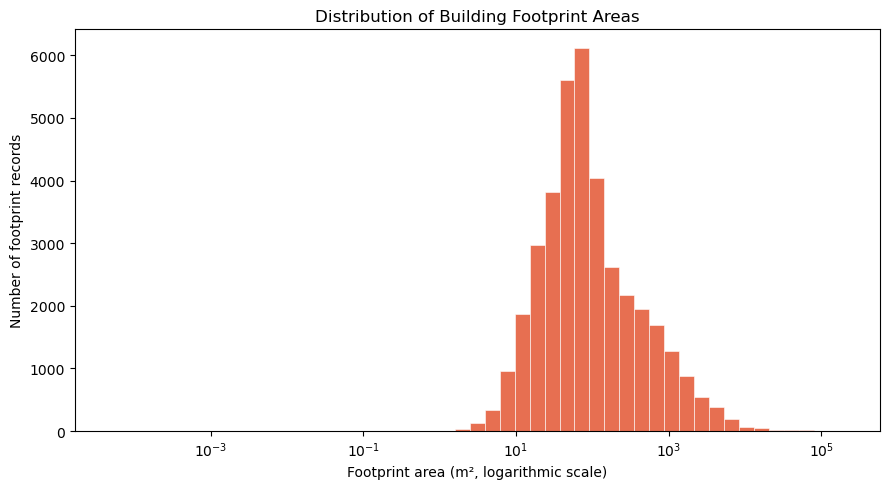

In [24]:
# Visualise the skewed footprint-area distribution on a log scale.
# Select positive footprint areas.
footprint_chart_data = building_projected.loc[
    building_projected["footprint_area_m2"] > 0,
    "footprint_area_m2"
]

# Create logarithmically spaced bins.
log_bins = np.logspace(
    np.log10(footprint_chart_data.min()),
    np.log10(footprint_chart_data.max()),
    50
)

# Plot the footprint-area distribution.
plt.figure(figsize=(9, 5))

plt.hist(
    footprint_chart_data,
    bins=log_bins,
    color="#E76F51",
    edgecolor="white",
    linewidth=0.4
)

plt.xscale("log")
plt.title("Distribution of Building Footprint Areas")
plt.xlabel("Footprint area (m², logarithmic scale)")
plt.ylabel("Number of footprint records")

save_and_show_figure(
    "building_footprint_area_distribution.png"
)

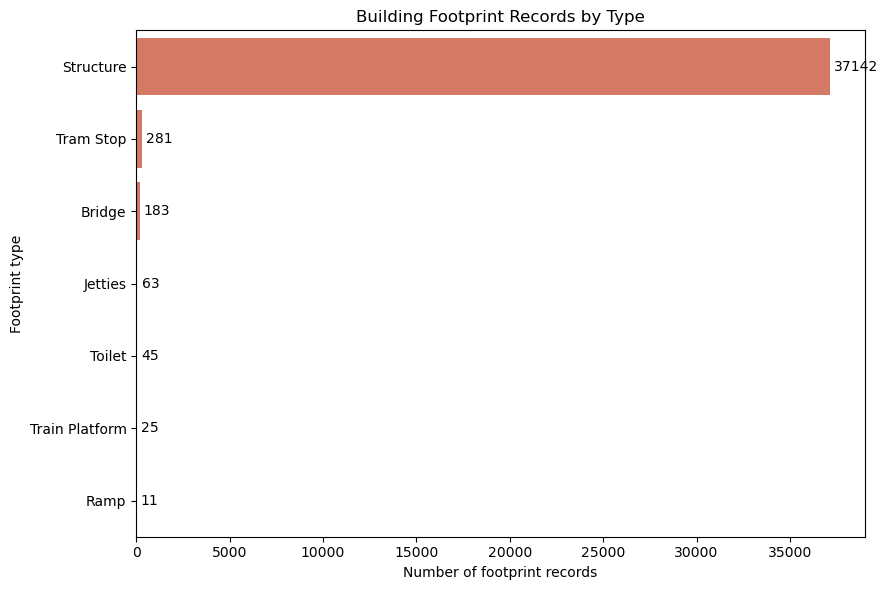

In [25]:
# Summarise footprint records by type.
footprint_type_summary = (
    building_clean["footprint_type"]
    .value_counts()
    .rename_axis("footprint_type")
    .reset_index(name="footprint_count")
)

# Visualise footprint records by type.
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=footprint_type_summary,
    x="footprint_count",
    y="footprint_type",
    color="#E76F51",
    errorbar=None
)

ax.set_title("Building Footprint Records by Type")
ax.set_xlabel("Number of footprint records")
ax.set_ylabel("Footprint type")

ax.bar_label(
    ax.containers[0],
    fmt="%.0f",
    padding=3
)

save_and_show_figure(
    "building_footprint_types.png"
)

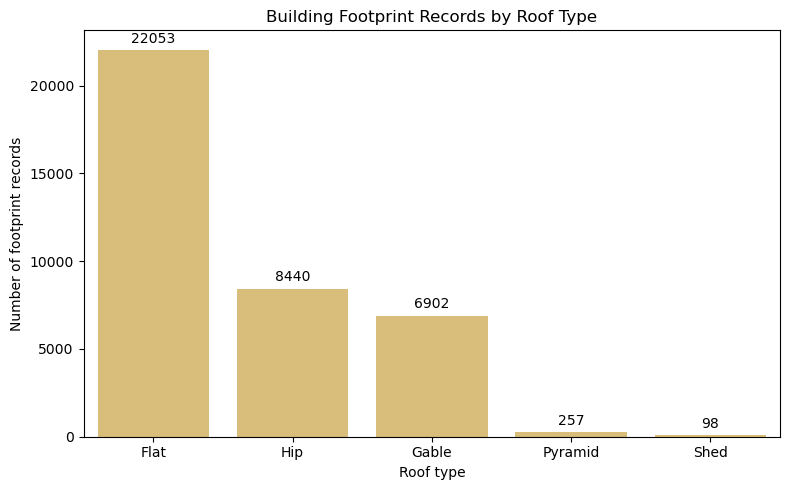

In [26]:
# Summarise footprint records by roof type.
roof_type_summary = (
    building_clean["roof_type"]
    .value_counts()
    .rename_axis("roof_type")
    .reset_index(name="footprint_count")
)

# Visualise footprint records by roof type.
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=roof_type_summary,
    x="roof_type",
    y="footprint_count",
    color="#E9C46A",
    errorbar=None
)

ax.set_title("Building Footprint Records by Roof Type")
ax.set_xlabel("Roof type")
ax.set_ylabel("Number of footprint records")

ax.bar_label(
    ax.containers[0],
    fmt="%.0f",
    padding=3
)

save_and_show_figure(
    "building_roof_types.png"
)

In [27]:
# Export the cleaned Building Footprints dataset.
building_export = (
    building_clean
    .drop(columns="geometry")
    .copy()
)

building_export.to_csv(
    CLEANED_DIR / "building_footprints_cleaned.csv",
    index=False
)

In [28]:
# Prepare the structure-level dataset for CSV export.
structure_export = (
    structure_gdf
    .to_crs("EPSG:4326")
    .copy()
)

structure_export["geometry_wkt"] = (
    structure_export.geometry.to_wkt()
)

structure_export = (
    structure_export
    .drop(columns="geometry")
)

structure_export.to_csv(
    CLEANED_DIR / "building_structure_summary.csv",
    index=False
)

# Export the category summaries used in the charts.
footprint_type_summary.to_csv(
    CLEANED_DIR / "building_footprint_type_summary.csv",
    index=False
)

roof_type_summary.to_csv(
    CLEANED_DIR / "building_roof_type_summary.csv",
    index=False
)

In [29]:
# Confirm that the expected Building Footprints files were created.
expected_output_files = [
    "building_footprints_cleaned.csv",
    "building_structure_summary.csv",
    "building_footprint_type_summary.csv",
    "building_roof_type_summary.csv"
]

for filename in expected_output_files:
    output_path = CLEANED_DIR / filename

    assert output_path.exists()

    print(f"Exported: {output_path}")

Exported: outputs/building_footprints/cleaned_data/building_footprints_cleaned.csv
Exported: outputs/building_footprints/cleaned_data/building_structure_summary.csv
Exported: outputs/building_footprints/cleaned_data/building_footprint_type_summary.csv
Exported: outputs/building_footprints/cleaned_data/building_roof_type_summary.csv


## Key Findings

- The Building Footprints dataset contained 37,750 footprint records and no exact duplicate rows.
- The dataset contained 19,018 unique `structure_id` values. A structure can have multiple footprint records because the source dataset represents changes in built form using vertically stacked footprint polygons.
- The combination of `structure_id` and `tier` was not unique. A total of 49 records were involved in 34 duplicated structure-tier combinations, so a new `footprint_record_id` was added to uniquely identify every footprint record.
- All GeoJSON geometries were successfully parsed. The dataset contained 37,746 MultiPolygon geometries and four Polygon geometries, with no missing, empty or invalid geometries.
- The median footprint area was 73.03 square metres and the mean was 413.62 square metres. The largest individual footprint area was 195,473.28 square metres.
- One footprint had a positive area below 0.01 square metres. It was retained because its geometry was valid and its area was greater than zero.
- The structure-level aggregation produced 19,018 unique structure records.

## Limitations

- The dataset represents structures within the City of Melbourne rather than the whole Greater Melbourne region.
- The data was captured in May 2020 and may not represent buildings that were constructed, demolished or modified after that date.
- A building footprint represents the boundary where a structure meets the ground plane or podium rather than the outline of its roof.
- Multiple footprint polygons may be vertically stacked to represent towers, podiums and setbacks. Therefore, the planar union of all tiers should not be interpreted as an exact ground-level boundary.
- The calculated footprint areas describe mapped two-dimensional polygon areas. They do not measure internal floor area, building occupancy or flood exposure.
- The elevation fields use the Australian Height Datum. The calculated elevation range should not automatically be interpreted as the exact physical height of a building.